<a href="https://colab.research.google.com/github/A-Ohanusi/Credit-Risk-Model-for-Lending-Against-Bitcoin-Collateral/blob/main/Bitcoin_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import numpy as np
from scipy.stats import skew, kurtosis


btc = yf.download(
    "BTC-USD",
    start="2018-01-01",
    auto_adjust=True
)

btc.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072


In [2]:
btc.to_csv("btc_raw.csv")

In [3]:
print(btc.isnull().sum())
print(btc.index.min())
print(btc.index.max())

Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64
2018-01-01 00:00:00
2026-07-02 00:00:00


In [4]:
import numpy as np

btc["log_return"] = np.log(
    btc["Close"] / btc["Close"].shift(1)
)

btc = btc.dropna()

In [5]:
btc["vol_30d"] = (
    btc["log_return"]
    .rolling(30)
    .std()
    * np.sqrt(365)
)

<Axes: title={'center': 'Bitcoin Price'}, xlabel='Date'>

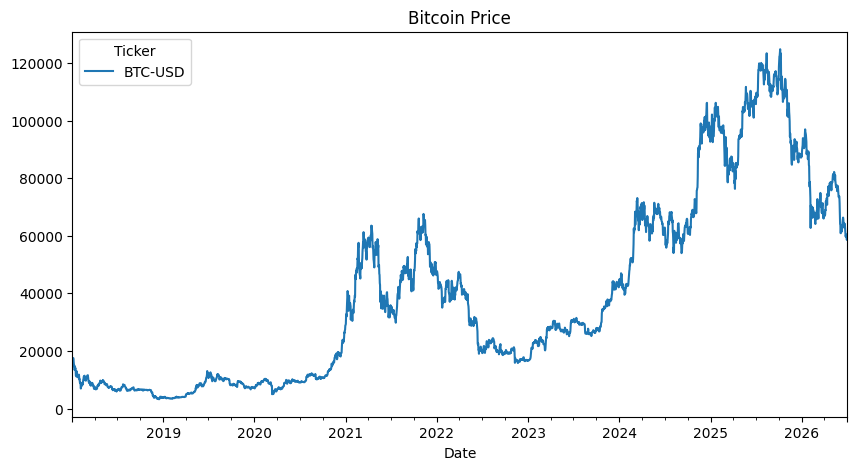

In [6]:
btc["Close"].plot(
    figsize=(10,5),
    title="Bitcoin Price"
)

<Axes: title={'center': 'Bitcoin Daily Log Returns'}, xlabel='Date'>

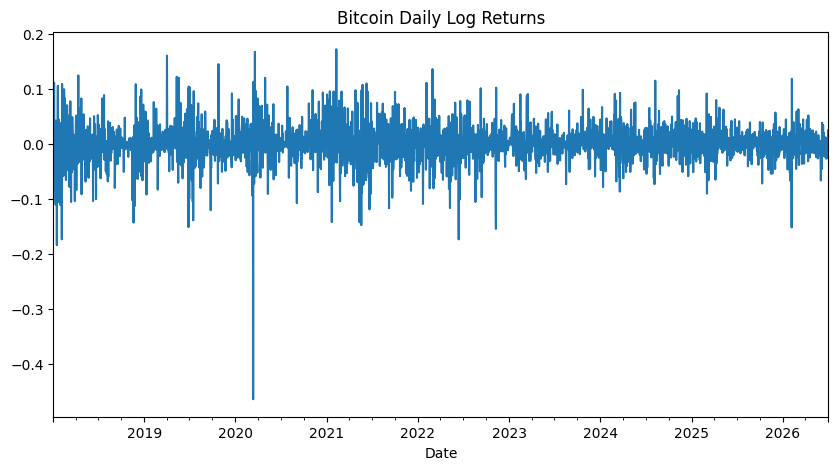

In [7]:
btc["log_return"].plot(
    figsize=(10,5),
    title="Bitcoin Daily Log Returns"
)

<Axes: title={'center': '30-Day Annualised Volatility'}, xlabel='Date'>

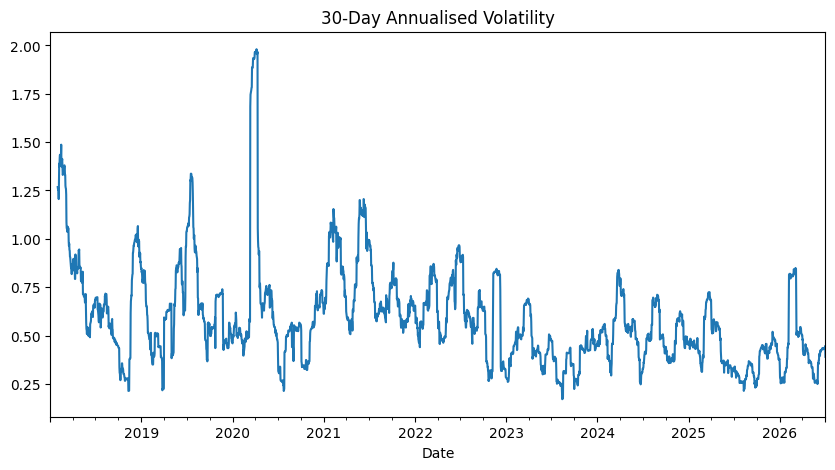

In [8]:
btc["vol_30d"].plot(
    figsize=(10,5),
    title="30-Day Annualised Volatility"
)

In [9]:
btc["log_return"].describe()

,log_return
count,3104.000000
mean,0.000479
std,0.033819
min,-0.464730
25%,-0.013689
50%,0.000623
75%,0.014954
max,0.171821


In [10]:
returns = btc["log_return"]

print("Mean:", returns.mean())
print("Volatility:", returns.std())
print("Skewness:", skew(returns))
print("Kurtosis:", kurtosis(returns))

Mean: 0.0004791942778541255
Volatility: 0.0338188852514806
Skewness: -0.9480982580281957
Kurtosis: 14.670300517032118
